In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [4]:
df=df.dropna()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [8]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

log_acc

0.8401639344262295

In [9]:
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

svm_acc

0.8333333333333334

In [10]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

rf_acc

0.837431693989071

In [11]:
print("Logistic Regression Accuracy:", log_acc)
print("SVM Accuracy:", svm_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.8401639344262295
SVM Accuracy: 0.8333333333333334
Random Forest Accuracy: 0.837431693989071


In [12]:
import shap

# Use Random Forest for SHAP (works best)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)

c:\Users\user\OneDrive\Desktop\Heart_Disease_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 94%|=================== | 1382/1464 [00:15<00:00]       

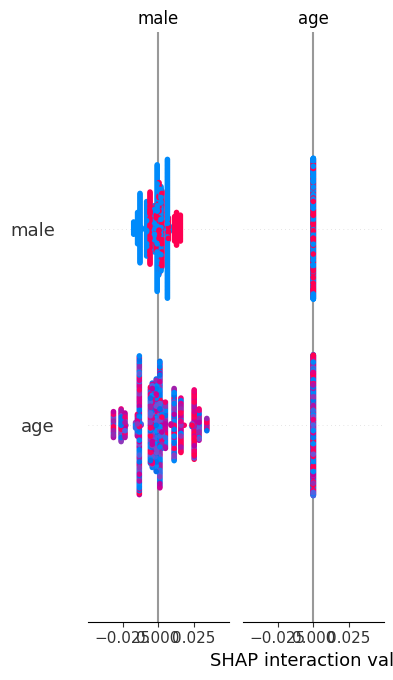

In [ ]:
import shap

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values.values, X_test, feature_names=X_test.columns)

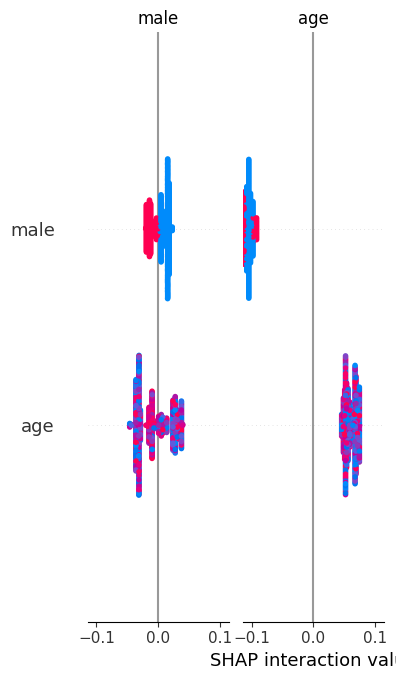

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is usually a list: shap_values[1]
try:
    shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)
except:
    # New SHAP versions return a single array
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [ ]:
import shap
shap.initjs()

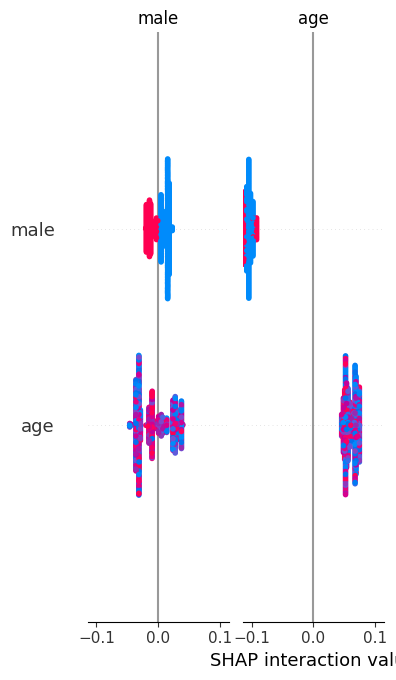

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# If shap returns two outputs (class 0, class 1)
try:
    shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)
except:
    # If shap returns only one array
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [ ]:
print("X_test shape:", X_test.shape)
print("SHAP values shape:", np.array(shap_values).shape)

X_test shape: (732, 15)
SHAP values shape: (732, 15, 2)


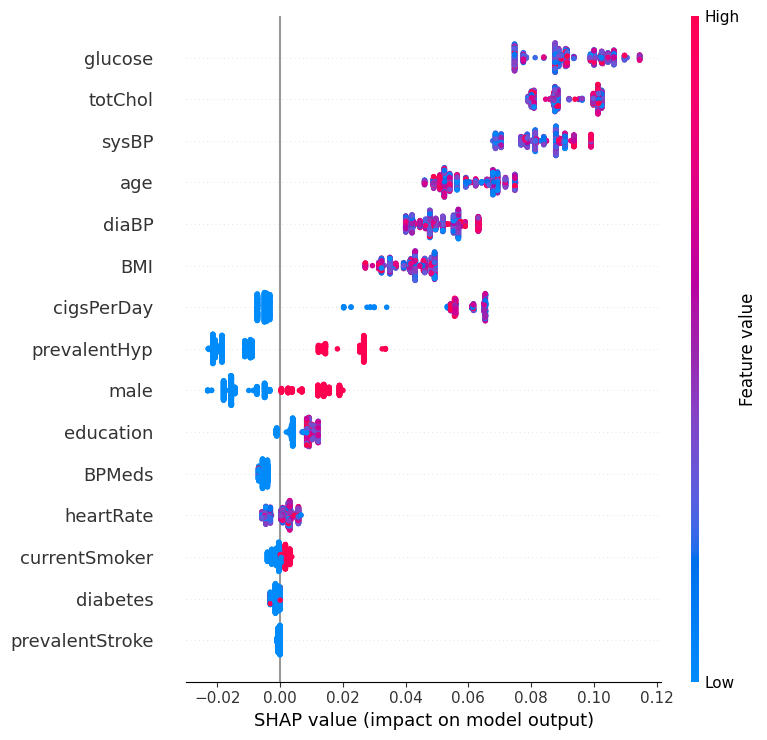

In [ ]:
import shap

# Initialize SHAP
shap.initjs()

# Create TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test)

# Select class 1 values  (index 1 because your last dimension = 2 classes)
shap_values_class1 = shap_values[:, :, 1]

# Generate Summary Plot
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns)

In [ ]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

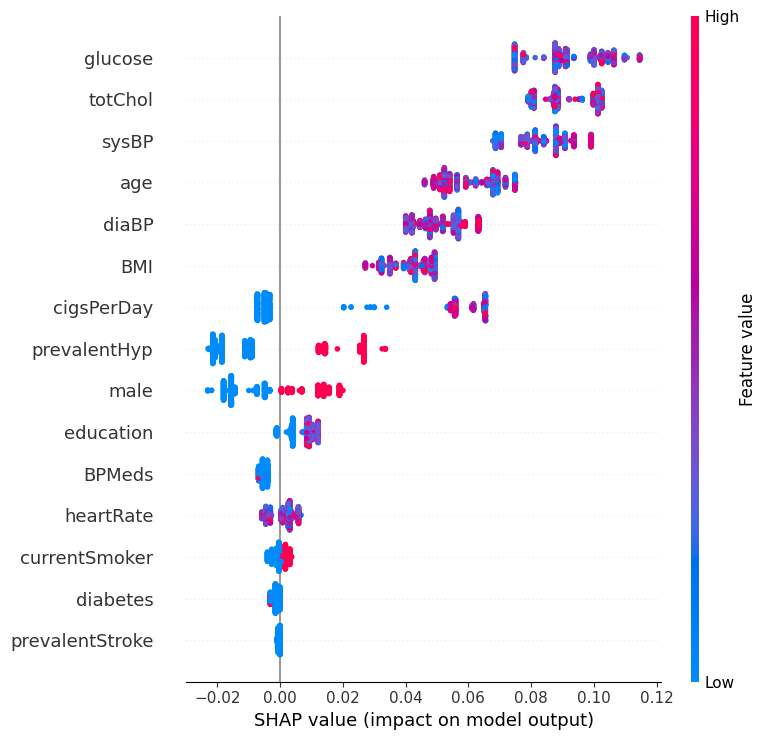

In [ ]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns)

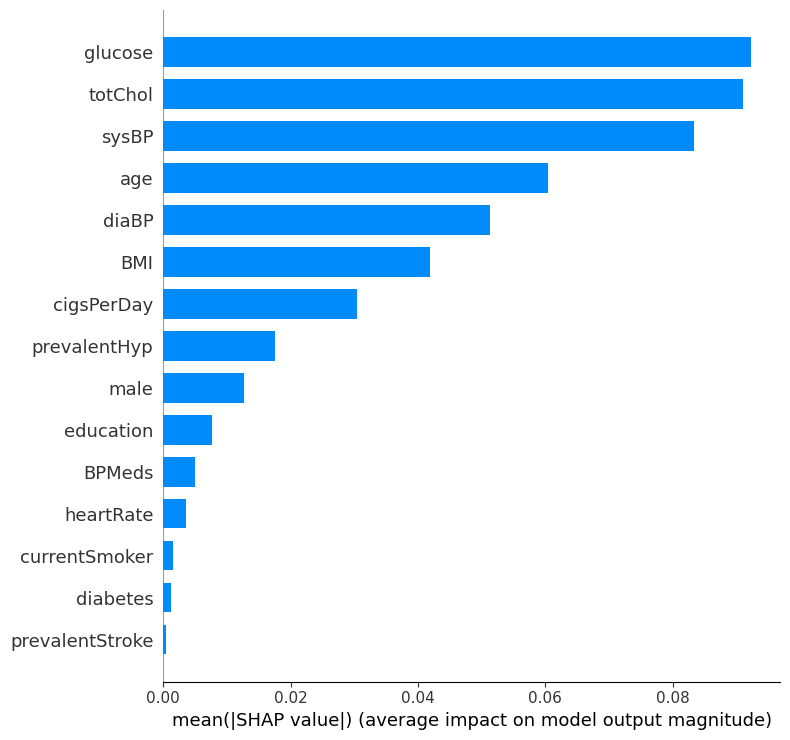

In [ ]:

shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns, plot_type="bar")


In [ ]:
sample_index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample_index],
    X_test.iloc[sample_index]
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[:50],   # first 50 samples
    X_test.iloc[:50]
)

In [ ]:
force_plot = shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[:50],
    X_test.iloc[:50]
)

shap.save_html("force_multiple.html", force_plot)

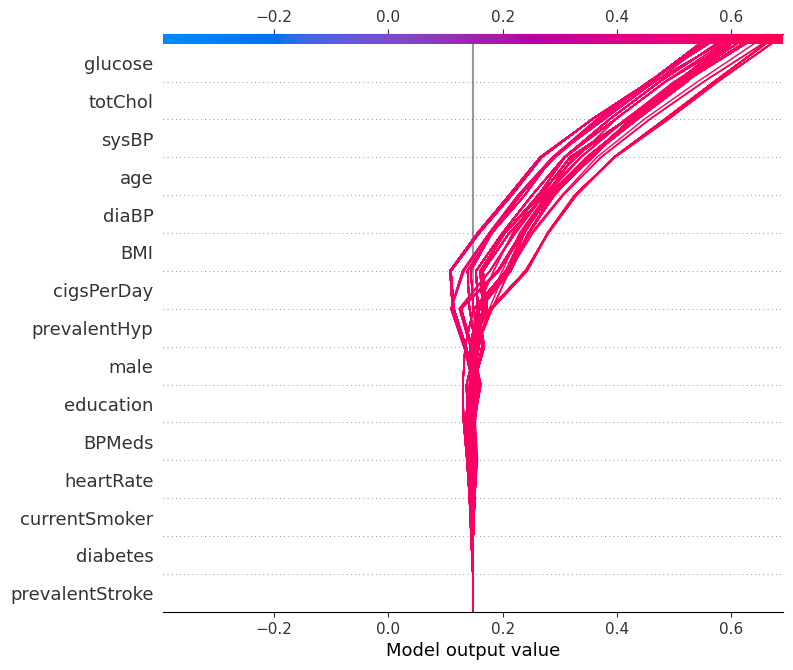

In [ ]:
shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    X_test.columns
)

In [ ]:
import pickle

# Save model
with open("heart_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
import pickle

# Save Random Forest Model
with open("heart_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')

In [13]:
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')


NameError: name 'plt' is not defined

In [ ]:
plt.savefig("shap_bar.png", dpi=300, bbox_inches='tight')

shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns)

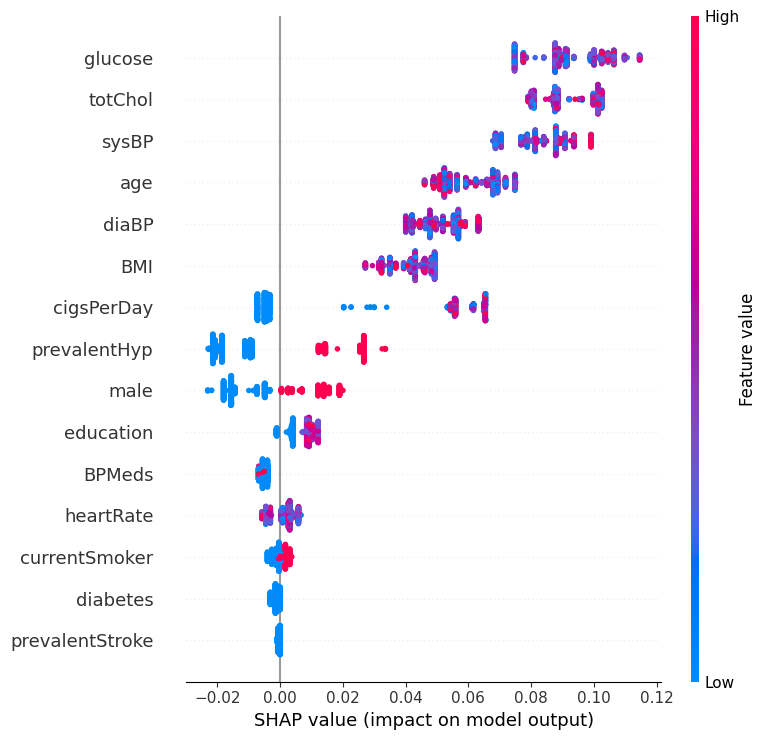

In [ ]:
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns)

In [ ]:
import matplotlib.pyplot as plt
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.close()

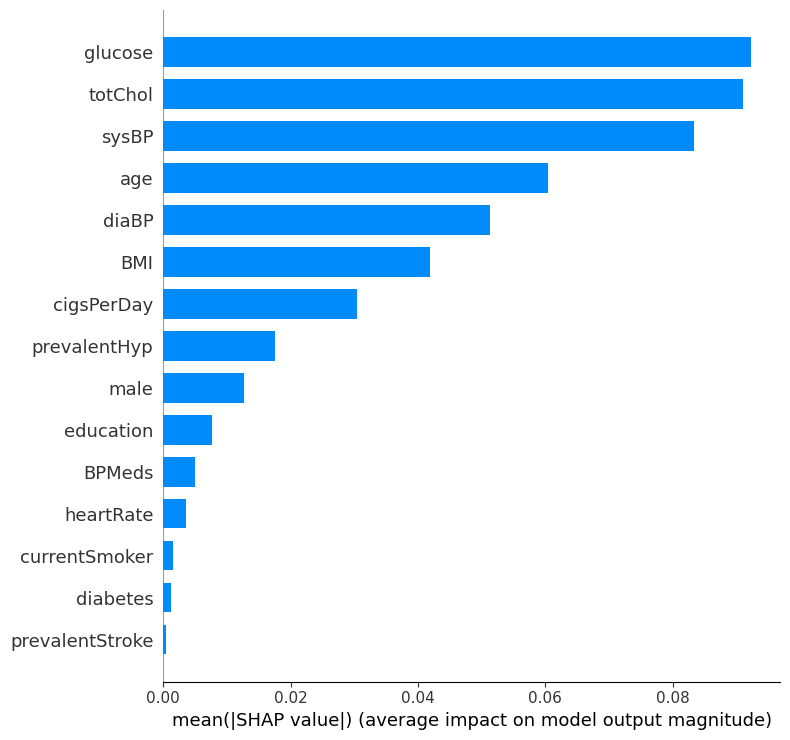

In [ ]:
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns, plot_type="bar")

In [ ]:
plt.savefig("shap_bar.png", dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
import matplotlib.pyplot as plt
plt.gcf().savefig("shap_summary.png", dpi=400, bbox_inches='tight')
plt.close()

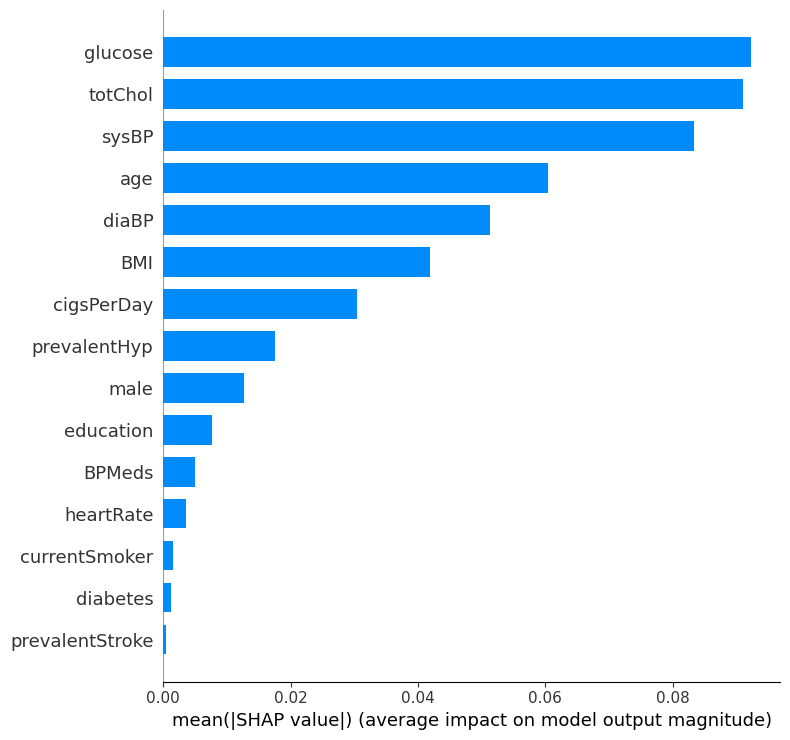

In [ ]:
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns, plot_type="bar")

In [ ]:
plt.gcf().savefig("shap_bar.png", dpi=400, bbox_inches='tight')
plt.close()

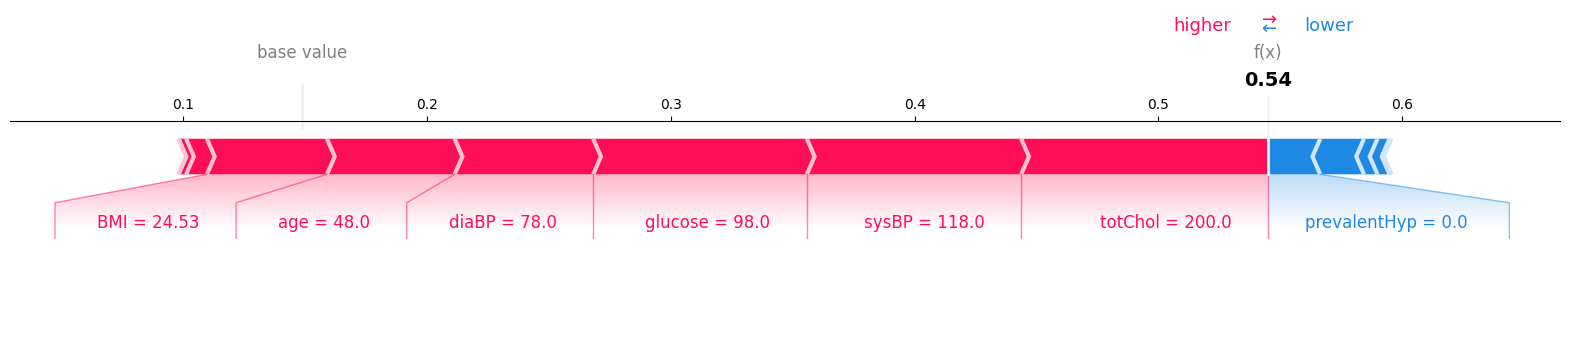

In [ ]:
sample_index = 0
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

In [ ]:
plt.gcf().savefig("shap_force_single.png", dpi=400, bbox_inches='tight')
plt.close()

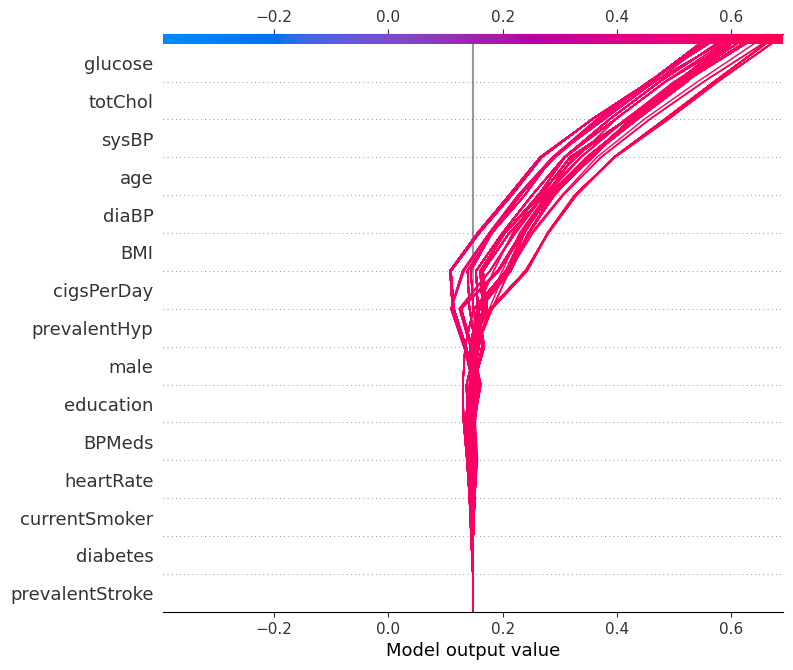

In [ ]:
shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    X_test.columns
)

In [ ]:
plt.gcf().savefig("shap_decision.png", dpi=400, bbox_inches='tight')
plt.close()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig = plt.figure()
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns, show=False)
plt.savefig("shap_summary.png", dpi=400, bbox_inches='tight')
plt.close(fig)

In [ ]:
fig = plt.figure()
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
plt.savefig("shap_bar.png", dpi=400, bbox_inches='tight')
plt.close(fig)

In [ ]:
fig = plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("shap_force.png", dpi=400, bbox_inches='tight')
plt.close(fig)

In [ ]:
fig = plt.figure()
shap.decision_plot(
    explainer.expected_value[1],
    shap_values_class1,
    X_test.columns,
    show=False
)
plt.savefig("shap_decision.png", dpi=400, bbox_inches='tight')
plt.close(fig)

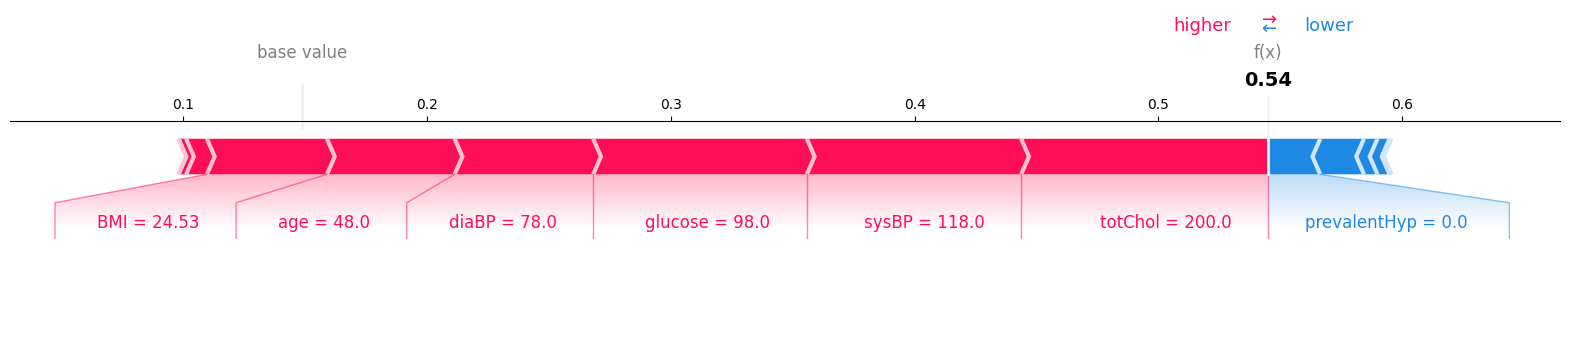

<Figure size 1200x400 with 0 Axes>

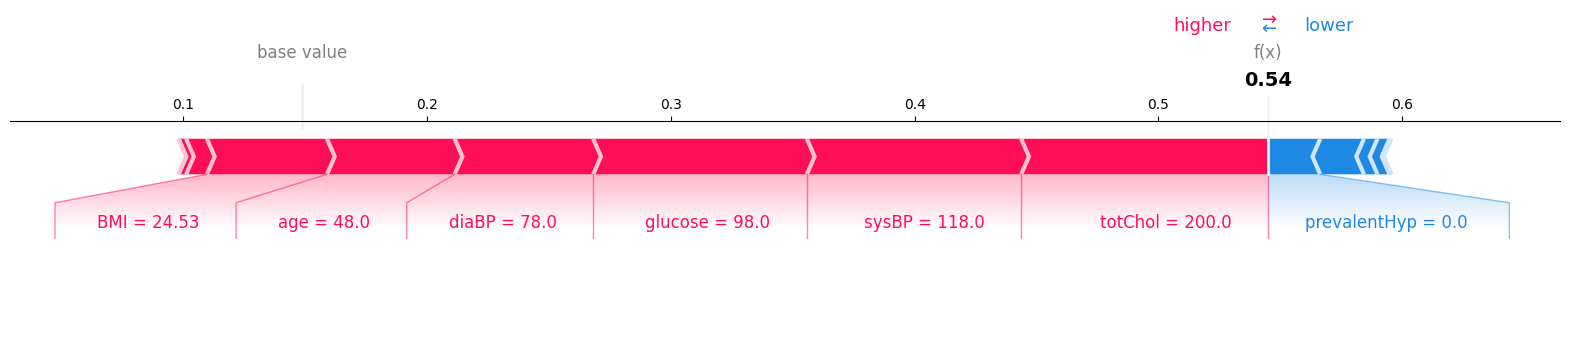

In [ ]:
import matplotlib.pyplot as plt

sample_index = 0

plt.figure(figsize=(12, 4))  # ensure figure is created

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True   # IMPORTANT
)

plt.savefig("shap_force_single.png", dpi=400, bbox_inches='tight')
plt.close()

<Figure size 1200x400 with 0 Axes>

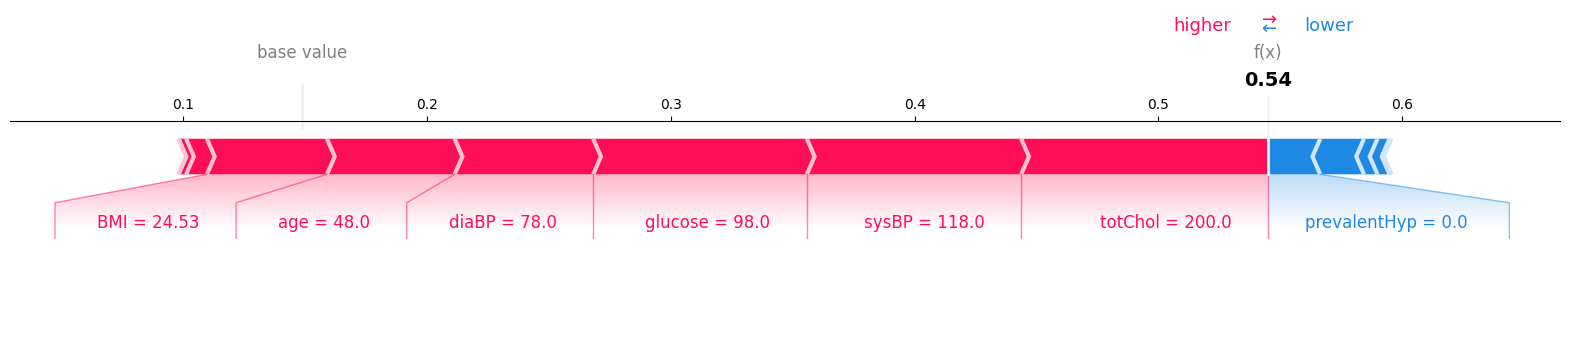

In [ ]:
from shap import plots

plt.figure(figsize=(12, 4))
plots.force(
    explainer.expected_value[1],
    shap_values_class1[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)
plt.savefig("shap_force_single.png", dpi=400, bbox_inches='tight')
plt.close()